# Whatsapp Group chat Analysis 

Summary :

### Step 1: Data load

In [112]:
#Loading and reading the data 
f = open('/Users/arpitalonakadi/Documents/GIT Final folders/Whatsapp chat analyser/WHATSAPP_GRP_CHAT.txt','r',encoding='utf-8')

data = f.read()

In [113]:
dummy = data.split('\n')
dummy

['[8/17/23, 12:04:14\u202fPM] OU US Santha: \u200eMessages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them.',
 '[8/17/23, 12:04:14\u202fPM] Arpita L India: \u200eArpita L India created this group',
 '[4/17/24, 10:27:05\u202fPM] OU US Santha: \u200eJittu Us added you',
 '\u200e[4/25/24, 2:53:44\u202fPM] Sandeep Ou M S Us: \u200eimage omitted',
 '\u200e[4/25/24, 2:53:45\u202fPM] Sandeep Ou M S Us: \u200eimage omitted',
 '[4/25/24, 2:54:55\u202fPM] Srilekha Palla Ou M S Us: May 9th poddune nen ochesta before you are awake 😛',
 '[4/25/24, 2:55:13\u202fPM] Sandeep Ou M S Us: I will wake up at 6am . 🤓🤓',
 '[4/25/24, 2:55:27\u202fPM] Srilekha Palla Ou M S Us: Aa okka roju 12 ki le 😛',
 '[4/25/24, 2:55:42\u202fPM] Harsha Tamu Ou: Andaru flight tickets sravya ki split mingandi',
 '\u200e[4/25/24, 2:59:24\u202fPM] Sandeep Ou M S Us: \u200esticker omitted',
 '[4/25/24, 2:59:33\u202fPM] Sandeep Ou M S Us: Job ochinaka esesta 300$',
 '[

### Step 2: Data Preprocessing 

In [114]:
# All necessary imports 
# Basic Libraries for Data Handling and Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Regular Expression for text parsing
import re

# Date and Time manipulation
from datetime import datetime

# File handling
import os

# For reading and processing text files
from collections import Counter

# For extracting and working with emojis
import emoji

# For word processing
import string

# For creating word clouds (optional)
from wordcloud import WordCloud

# For machine learning or advanced text analysis (optional)
from sklearn.feature_extraction.text import CountVectorizer

# Optional: To handle large datasets (useful if you expect large chat files)
import dask.dataframe as dd

# For handling the text message splitting and cleaning
import string

In [115]:
# Define regex pattern to capture date-time and user-message part.
# This pattern captures the date-time and separates it from the user and message.
pattern = r'\[\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}:\d{2}\s\w{2}\]\s'  # Date-Time Pattern
messages = re.split(pattern, data)[1:]  # Extract messages after the date-time
dates = re.findall(pattern, data)  # Extract dates

# Clean the extracted messages (strip extra whitespace)
messages = [msg.strip() for msg in messages]

# Print out the number of messages and dates
print(f"Number of messages: {len(messages)}")
print(f"Number of dates: {len(dates)}")

# Optionally print out the first few messages and dates
for i in range(min(5, len(messages))):
    print(f"Date: {dates[i]}, Message: {messages[i]}")

Number of messages: 570
Number of dates: 570
Date: [8/17/23, 12:04:14 PM] , Message: OU US Santha: ‎Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them.
Date: [8/17/23, 12:04:14 PM] , Message: Arpita L India: ‎Arpita L India created this group
Date: [4/17/24, 10:27:05 PM] , Message: OU US Santha: ‎Jittu Us added you
‎
Date: [4/25/24, 2:53:44 PM] , Message: Sandeep Ou M S Us: ‎image omitted
‎
Date: [4/25/24, 2:53:45 PM] , Message: Sandeep Ou M S Us: ‎image omitted


In [116]:

# Example string
string = '[8/17/23, 12:04:14 PM]'
    # Remove the square brackets and the non-breaking space
string = string.strip('[]').replace(' ', ' ')
    
    # Split the string by comma to get the date and time
date, time = string.split(',')
    
    # Trim any extra spaces and remove trailing ']'
time = time.strip().rstrip(']')

    # Convert the time to 24-hour format using datetime
time_24hr = datetime.strptime(time, '%I:%M:%S %p').strftime('%H:%M')


print(f"Date: {date} and Time: {time_24hr}")

Date: 8/17/23 and Time: 12:04


In [117]:
from datetime import datetime

def gettimeanddate(string):
    # Remove the square brackets and the non-breaking space
    string = string.strip('[]').replace(' ', ' ')

    # Split the string by comma to get the date and time
    date, time = string.split(',')

    # Trim any extra spaces

    time = time.strip().rstrip(']')

    # Convert the time to 24-hour format using datetime
    time_24hr = datetime.strptime(time, '%I:%M:%S %p').strftime('%H:%M')

    return date + " " + time_24hr

In [118]:
# Create DataFrame with messages and dates
df = pd.DataFrame({
    'user_messages': messages,
    'message_date': dates  # assuming you have the 'dates' list populated
})

# Apply the function to format the 'message_date' column
df['message_date'] = df['message_date'].apply(lambda text: gettimeanddate(text))

# Rename columns for consistency
df.rename(columns={'message_date': 'date'}, inplace=True)

# Display the first few rows
print(df.head())

                                       user_messages           date
0  OU US Santha: ‎Messages and calls are end-to-e...  8/17/23 12:04
1  Arpita L India: ‎Arpita L India created this g...  8/17/23 12:04
2               OU US Santha: ‎Jittu Us added you\n‎  4/17/24 22:27
3               Sandeep Ou M S Us: ‎image omitted\n‎  4/25/24 14:53
4                  Sandeep Ou M S Us: ‎image omitted  4/25/24 14:53


In [119]:
df['user_messages']

0      OU US Santha: ‎Messages and calls are end-to-e...
1      Arpita L India: ‎Arpita L India created this g...
2                   OU US Santha: ‎Jittu Us added you\n‎
3                   Sandeep Ou M S Us: ‎image omitted\n‎
4                      Sandeep Ou M S Us: ‎image omitted
                             ...                        
565             Srilekha Palla Ou M S Us: ‎image omitted
566                            Sandeep Ou M S Us: Wow! 😋
567                              Harsha Tamu Ou: Cwazyyy
568                             Moki Ou M S: Happy Ugadi
569            Anusha Aligeti USA: Happyyy ugadi guysss!
Name: user_messages, Length: 570, dtype: object

In [120]:
import re

# List of phrases that should be classified as 'Group Notification'
group_notification_phrases = [
    'Messages and calls are end-to-end encrypted',
    'created this group', 'added you'
]

# Lists to store users and messages
users = []
messages = []

for message in df['user_messages']:
    
    # Check if the message contains any of the predefined phrases
    if any(phrase in message for phrase in group_notification_phrases):
        users.append('Group Notification')
        messages.append(message)
    else:
        # Split the message to extract the user and message
        entry = re.split('([\w\W]+?):\s', message)
        if entry[1:]:
            users.append(entry[1])  # Add the user
            messages.append(entry[2])  # Add the message
        else:
            # For any other type of message (like notifications), we classify as 'Group Notification'
            users.append('Group Notification')
            messages.append(entry[0])

# Adding the 'User' and 'Message' columns to the dataframe
df['User'] = users
df['message'] = messages

# Function to clean the message (removing extra newline characters)
def getstring(text):
    return text.split('\n')[0]

# Apply the cleaning function to the message column
df['message'] = df['message'].apply(lambda text: getstring(text))

# Drop the original 'user_messages' column
df = df.drop(['user_messages'], axis=1)

# Reorder the columns for consistency
df = df[['message', 'date', 'User']]

# Rename columns for consistency
df = df.rename(columns={'message': 'Message', 'date': 'Date'})

# Display the first few rows of the DataFrame
print(df.head(30))

                                              Message           Date  \
0   OU US Santha: ‎Messages and calls are end-to-e...  8/17/23 12:04   
1   Arpita L India: ‎Arpita L India created this g...  8/17/23 12:04   
2                   OU US Santha: ‎Jittu Us added you  4/17/24 22:27   
3                                      ‎image omitted  4/25/24 14:53   
4                                      ‎image omitted  4/25/24 14:53   
5   May 9th poddune nen ochesta before you are awa...  4/25/24 14:54   
6                          I will wake up at 6am . 🤓🤓  4/25/24 14:55   
7                             Aa okka roju 12 ki le 😛  4/25/24 14:55   
8      Andaru flight tickets sravya ki split mingandi  4/25/24 14:55   
9                                    ‎sticker omitted  4/25/24 14:59   
10                           Job ochinaka esesta 300$  4/25/24 14:59   
11  Ne grad ki ochinanduku neeku mingara flight ti...  4/25/24 15:02   
12                           Naa grad ki evar raale 😌  4/25/24 1

In [121]:

# Display the DataFrame
print(df.head(4))

                                             Message           Date  \
0  OU US Santha: ‎Messages and calls are end-to-e...  8/17/23 12:04   
1  Arpita L India: ‎Arpita L India created this g...  8/17/23 12:04   
2                  OU US Santha: ‎Jittu Us added you  4/17/24 22:27   
3                                     ‎image omitted  4/25/24 14:53   

                 User  
0  Group Notification  
1  Group Notification  
2  Group Notification  
3   Sandeep Ou M S Us  


In [122]:
df.shape

(570, 3)

In [123]:
df['Only date'] = pd.to_datetime(df['Date']).dt.date

df['Year'] = pd.to_datetime(df['Date']).dt.year

df['Month_num'] = pd.to_datetime(df['Date']).dt.month

df['Month'] = pd.to_datetime(df['Date']).dt.month_name()

df['Day'] = pd.to_datetime(df['Date']).dt.day

df['Day_name'] = pd.to_datetime(df['Date']).dt.day_name()


df['Hour'] = pd.to_datetime(df['Date']).dt.hour

df['Minute'] = pd.to_datetime(df['Date']).dt.minute


df.head()

/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_34714/2879012235.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Only date'] = pd.to_datetime(df['Date']).dt.date
/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_34714/2879012235.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Year'] = pd.to_datetime(df['Date']).dt.year
/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_34714/2879012235.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month_num'] = pd.to_datetime(df['Date']).dt.month
/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0

,Message,Date,User,Only date,Year,Month_num,Month,Day,Day_name,Hour,Minute
0,OU US Santha: ‎Messages and calls are end-to-e...,8/17/23 12:04,Group Notification,2023-08-17,2023,8,August,17,Thursday,12,4
1,Arpita L India: ‎Arpita L India created this g...,8/17/23 12:04,Group Notification,2023-08-17,2023,8,August,17,Thursday,12,4
2,OU US Santha: ‎Jittu Us added you,4/17/24 22:27,Group Notification,2024-04-17,2024,4,April,17,Wednesday,22,27
3,‎image omitted,4/25/24 14:53,Sandeep Ou M S Us,2024-04-25,2024,4,April,25,Thursday,14,53
4,‎image omitted,4/25/24 14:53,Sandeep Ou M S Us,2024-04-25,2024,4,April,25,Thursday,14,53


##### Saving the preprocessed data 

In [129]:
df.to_csv('/Users/arpitalonakadi/Documents/GIT Final folders/preprocessed_chat_data.csv', index=False)

### Step 3: Running preliminaty analysis

In [38]:
import pandas as pd

# Load the preprocessed data (assuming you saved it as CSV previously)
df = pd.read_csv('/Users/arpitalonakadi/Documents/GIT Final folders/preprocessed_chat_data.csv')

# Check the first few rows
print(df.head())

                                             Message           Date  \
0  OU US Santha: ‎Messages and calls are end-to-e...  8/17/23 12:04   
1  Arpita L India: ‎Arpita L India created this g...  8/17/23 12:04   
2                  OU US Santha: ‎Jittu Us added you  4/17/24 22:27   
3                                     ‎image omitted  4/25/24 14:53   
4                                     ‎image omitted  4/25/24 14:53   

                 User   Only date  Year  Month_num   Month  Day   Day_name  \
0  Group Notification  2023-08-17  2023          8  August   17   Thursday   
1  Group Notification  2023-08-17  2023          8  August   17   Thursday   
2  Group Notification  2024-04-17  2024          4   April   17  Wednesday   
3   Sandeep Ou M S Us  2024-04-25  2024          4   April   25   Thursday   
4   Sandeep Ou M S Us  2024-04-25  2024          4   April   25   Thursday   

   Hour  Minute  
0    12       4  
1    12       4  
2    22      27  
3    14      53  
4    14      5

In [39]:
# Group by User and count messages
user_engagement = df['User'].value_counts()

# Display the most active users
print(user_engagement)

User
Anusha Aligeti USA          116
Arpita                      103
Sandeep Ou M S Us            91
Sravya Ou M S Us Perm        89
Srilekha Palla Ou M S Us     41
Subbi Boi Ou M S Us          38
Moki Ou M S                  31
Harsha Tamu Ou               30
Vineeth Bvt Ou M S Us        15
Jittu Us                     12
Group Notification            3
Tej nsha Frnd                 1
Name: count, dtype: int64


In [40]:
# Most active user
most_active_user = user_engagement.idxmax()
most_active_user_messages = user_engagement.max()

print(f"Most active user: {most_active_user} with {most_active_user_messages} messages")

Most active user: Anusha Aligeti USA with 116 messages


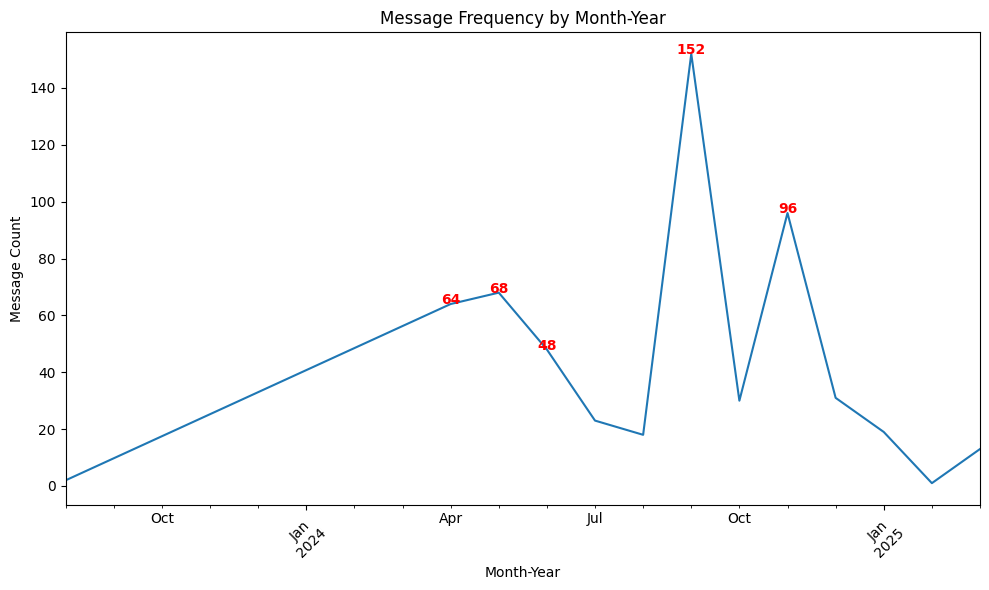

In [41]:
import matplotlib.pyplot as plt

# Ensure the 'Only date' column is in datetime format
df['Only date'] = pd.to_datetime(df['Only date'], errors='coerce')

# Group by Year and Month to count messages
df['Month_Year'] = df['Only date'].dt.to_period('M')  # Convert to Month-Year format
message_frequency_by_month_year = df.groupby('Month_Year').count()['Message']

# Find the top 5 peaks
top_5_peaks = message_frequency_by_month_year.nlargest(5)

# Plotting the message frequency by Month-Year
plt.figure(figsize=(10, 6))
message_frequency_by_month_year.plot(kind='line', title='Message Frequency by Month-Year')

# Add labels for the top 5 peaks
for peak in top_5_peaks.index:
    plt.text(peak, top_5_peaks[peak], str(top_5_peaks[peak]), ha='center', color='red', fontweight='bold')

# Customizing the plot
plt.xlabel('Month-Year')
plt.ylabel('Message Count')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

In [42]:
pip install textblob

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


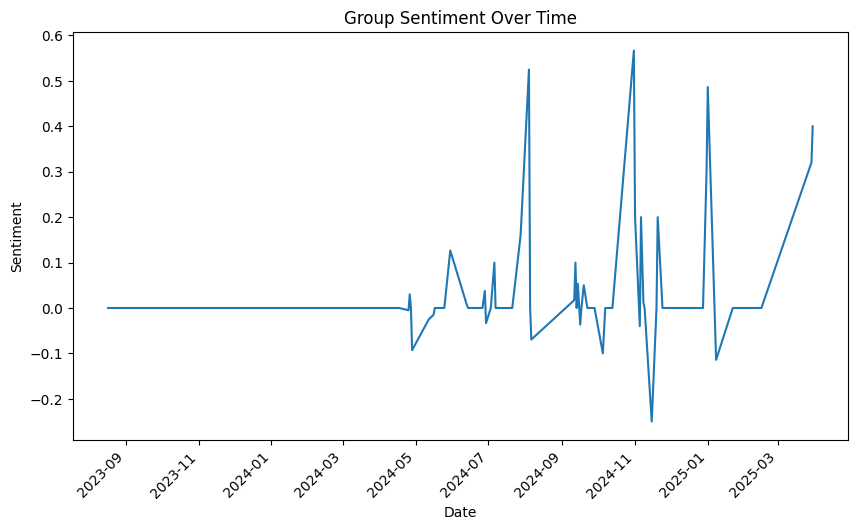

In [43]:
from textblob import TextBlob

# Function to get sentiment of a message
def get_sentiment(text):
    # Check if text is a string (non-null)
    if isinstance(text, str):
        analysis = TextBlob(text)
        return analysis.sentiment.polarity
    return 0  # Return 0 sentiment for non-string entries (such as NaN)

# Apply sentiment function to the message column
df['sentiment'] = df['Message'].apply(get_sentiment)

# Group sentiment by date
sentiment_by_date = df.groupby('Only date')['sentiment'].mean()

# Plot sentiment over time
plt.figure(figsize=(10, 6))
sentiment_by_date.plot(kind='line', title='Group Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Sentiment')
plt.xticks(rotation=45)
plt.show()

In [44]:
from collections import Counter
import re

# Ensure all values in 'Message' are strings and replace NaN with empty string
df['Message'] = df['Message'].fillna('')

# Remove non-alphabetical characters and split messages into words
all_words = ' '.join(df['Message']).lower()
all_words = re.sub(r'[^a-z\s]', '', all_words)

# Split the words and count their frequency
word_freq = Counter(all_words.split())

# Display the 10 most common words
print(word_freq.most_common(10))

[('omitted', 115), ('sticker', 74), ('image', 28), ('ra', 22), ('happy', 21), ('you', 18), ('ki', 18), ('this', 17), ('guys', 17), ('call', 17)]


/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_36512/1806842289.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('RdYlGn')  # Red-Yellow-Green color map


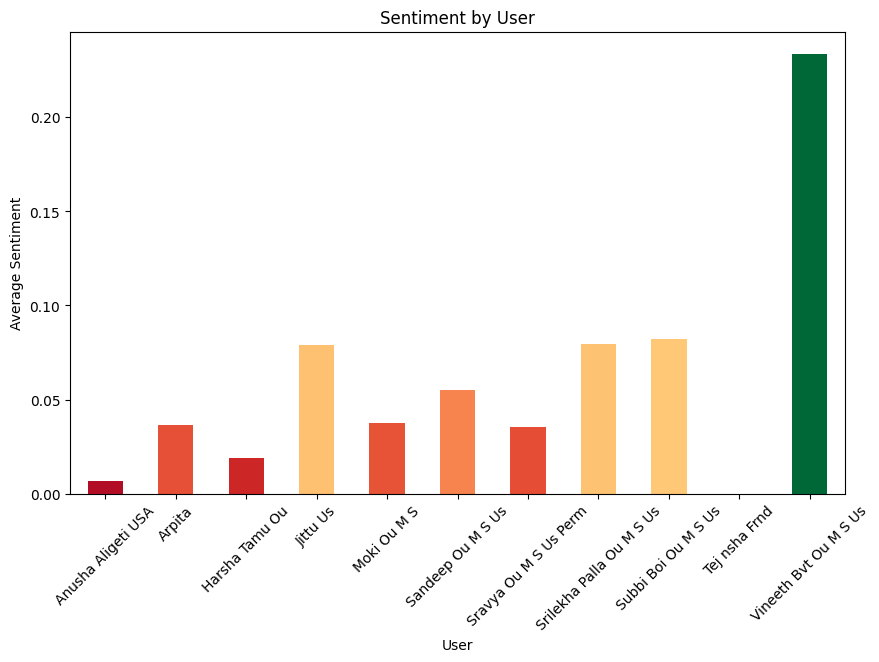

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Remove 'Group Notification' from the dataset
sentiment_by_user = df[df['User'] != 'Group Notification'].groupby('User')['sentiment'].mean()

# Create a color map based on sentiment values
colors = plt.cm.get_cmap('RdYlGn')  # Red-Yellow-Green color map

# Normalize sentiment values to range from 0 to 1 for color mapping
norm = plt.Normalize(sentiment_by_user.min(), sentiment_by_user.max())

# Plot sentiment by user with color gradient
plt.figure(figsize=(10, 6))

# Apply color gradient to the bar chart
bars = sentiment_by_user.plot(kind='bar', color=colors(norm(sentiment_by_user)), title='Sentiment by User')

# Adding labels
plt.xlabel('User')
plt.ylabel('Average Sentiment')
plt.xticks(rotation=45)

# Display the plot
plt.show()

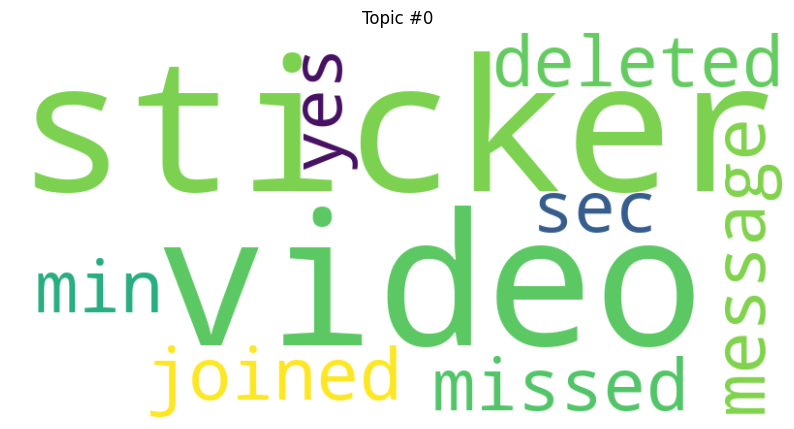

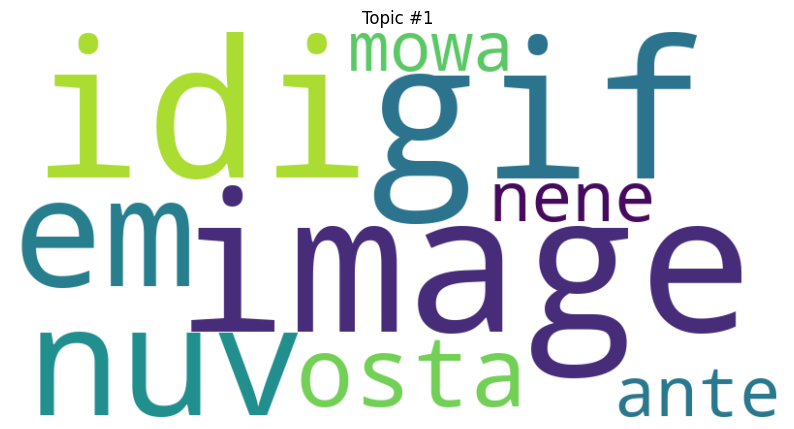

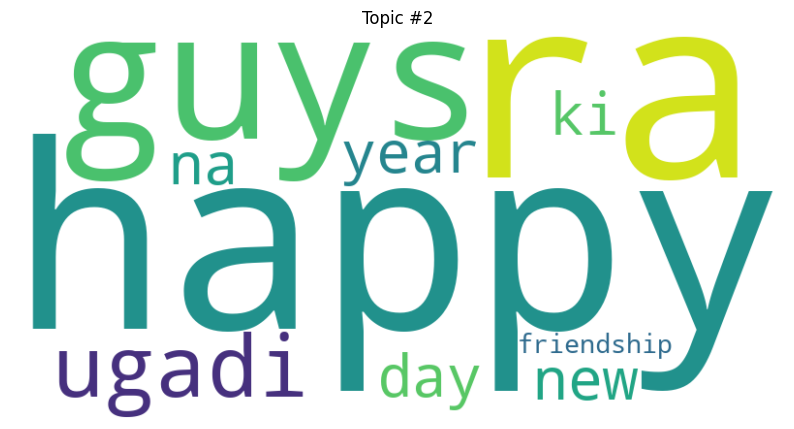

In [46]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize the messages to a TF-IDF matrix
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['Message'])

# Apply LDA to extract topics
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

# Function to generate word cloud from topic words
def generate_wordcloud(topic_idx, topic, vectorizer):
    # Get the top words for the topic
    topic_words = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-10 - 1:-1]]
    
    # Remove the word "omitted" from the list if it exists
    topic_words = [word for word in topic_words if word != 'omitted']
    
    # Join the words and create a string for wordcloud
    topic_text = ' '.join(topic_words)
    
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(topic_text)
    
    # Plot the wordcloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Topic #{topic_idx}")
    plt.show()

# Generate word clouds for each topic
for topic_idx, topic in enumerate(lda.components_):
    generate_wordcloud(topic_idx, topic, vectorizer)

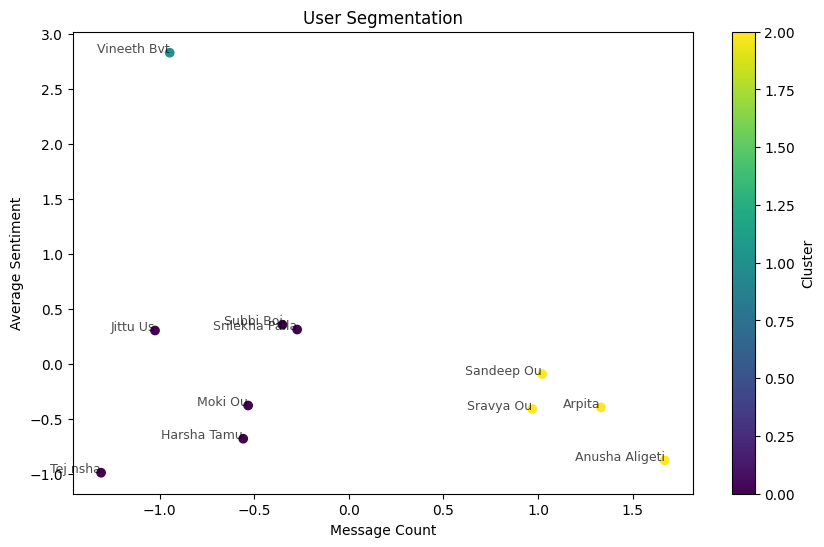

In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Filter out 'Group Notification' users
user_data = df[df['User'] != 'Group Notification']

# Segment users based on activity (message count, sentiment)
user_data = user_data.groupby('User').agg({'Message': 'count', 'sentiment': 'mean'}).reset_index()

# Normalize the data
scaler = StandardScaler()
user_data[['Message', 'sentiment']] = scaler.fit_transform(user_data[['Message', 'sentiment']])

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
user_data['Cluster'] = kmeans.fit_predict(user_data[['Message', 'sentiment']])

# Visualize the clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(user_data['Message'], user_data['sentiment'], c=user_data['Cluster'], cmap='viridis')

# Adding labels for each user (first two words of the user's name)
for i in range(len(user_data)):
    user_name = user_data['User'].iloc[i]
    label = ' '.join(user_name.split()[:2])  # Take the first two words
    plt.text(user_data['Message'].iloc[i], user_data['sentiment'].iloc[i], label, 
             fontsize=9, alpha=0.7, ha='right', color='black')

plt.title('User Segmentation')
plt.xlabel('Message Count')
plt.ylabel('Average Sentiment')
plt.colorbar(scatter, label='Cluster')
plt.show()

/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_36512/3788277641.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


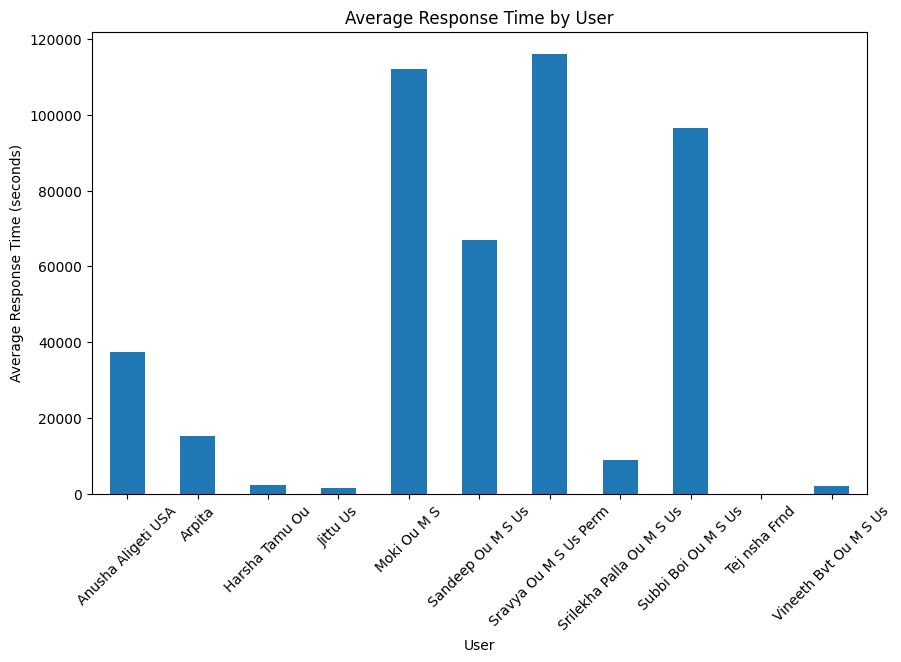

In [48]:
# Convert the date to datetime for easier comparison
df['Date'] = pd.to_datetime(df['Date'])

# Calculate response time (time difference between consecutive messages)
df['response_time'] = df['Date'].diff().dt.total_seconds()

# Remove 'Group Notification' from the DataFrame
df_filtered = df[df['User'] != 'Group Notification']

# Group by User to get average response time, excluding 'Group Notification'
response_time_by_user = df_filtered.groupby('User')['response_time'].mean()

# Plot response time by user
plt.figure(figsize=(10, 6))
response_time_by_user.plot(kind='bar', title='Average Response Time by User')
plt.xlabel('User')
plt.ylabel('Average Response Time (seconds)')
plt.xticks(rotation=45)
plt.show()

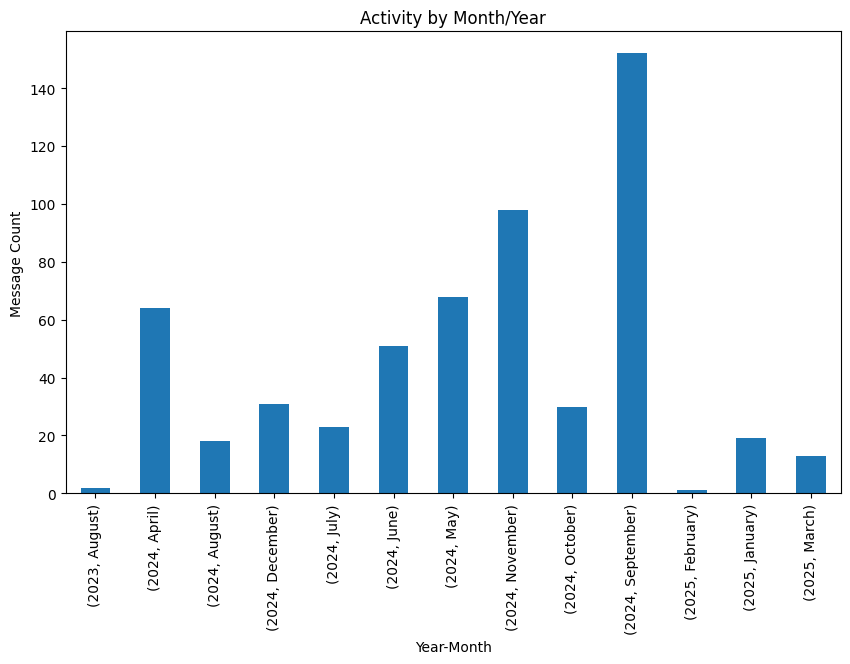

In [49]:
# Group by Year and Month to count messages
activity_by_month_year = df.groupby(['Year', 'Month']).count()['Message']

# Plotting
activity_by_month_year.plot(kind='bar', figsize=(10, 6), title='Activity by Month/Year')
plt.xlabel('Year-Month')
plt.ylabel('Message Count')
plt.show()

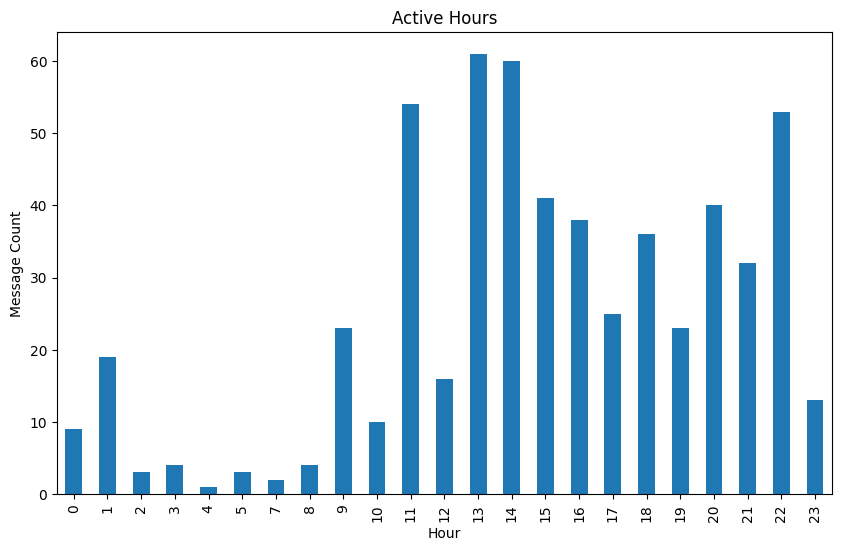

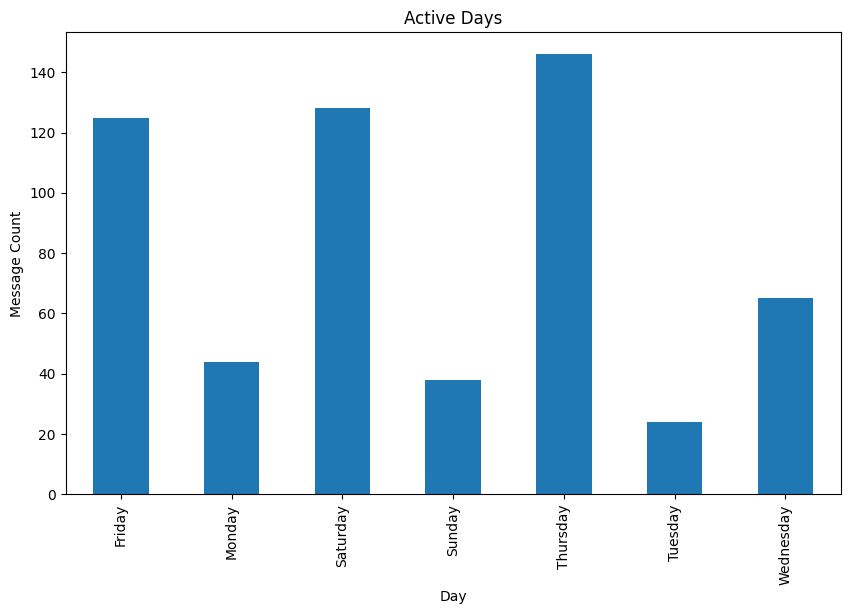

In [50]:
# Group by Hour to find active hours
activity_by_hour = df.groupby('Hour').count()['Message']

# Group by Day of Week for active days
activity_by_day = df.groupby('Day_name').count()['Message']

# Plot active hours
activity_by_hour.plot(kind='bar', figsize=(10, 6), title='Active Hours')
plt.xlabel('Hour')
plt.ylabel('Message Count')
plt.show()

# Plot active days
activity_by_day.plot(kind='bar', figsize=(10, 6), title='Active Days')
plt.xlabel('Day')
plt.ylabel('Message Count')
plt.show()

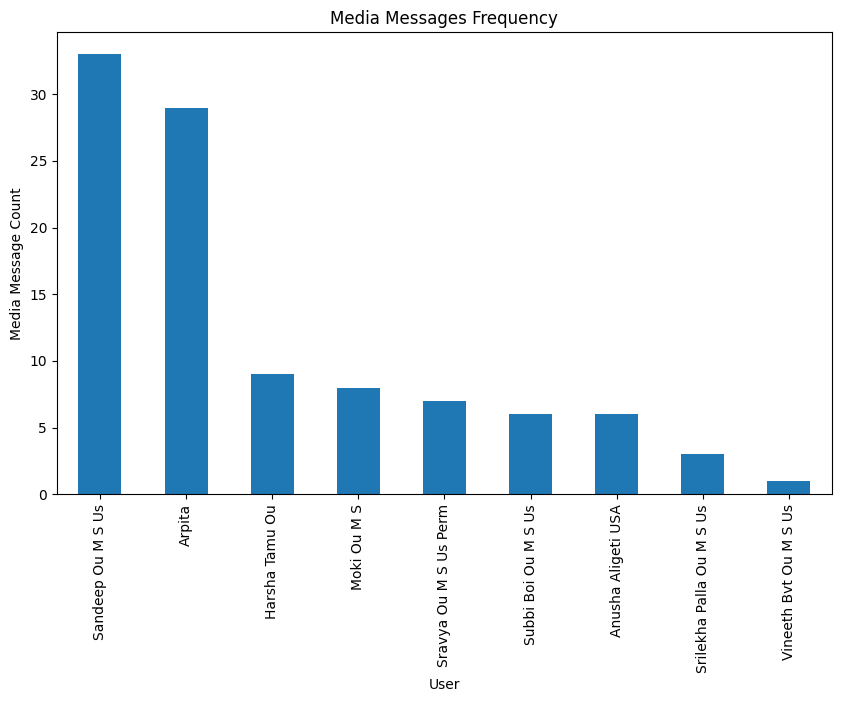

In [51]:
# Filter for media-related messages (e.g., "<Media omitted>")
media_messages = df[df['Message'].str.contains('image omitted|sticker omitted', case=False)]

# Count media messages
media_count = media_messages['Message'].count()

# Plot media message count
plt.figure(figsize=(10, 6))
media_messages['User'].value_counts().plot(kind='bar', title='Media Messages Frequency')
plt.xlabel('User')
plt.ylabel('Media Message Count')
plt.show()

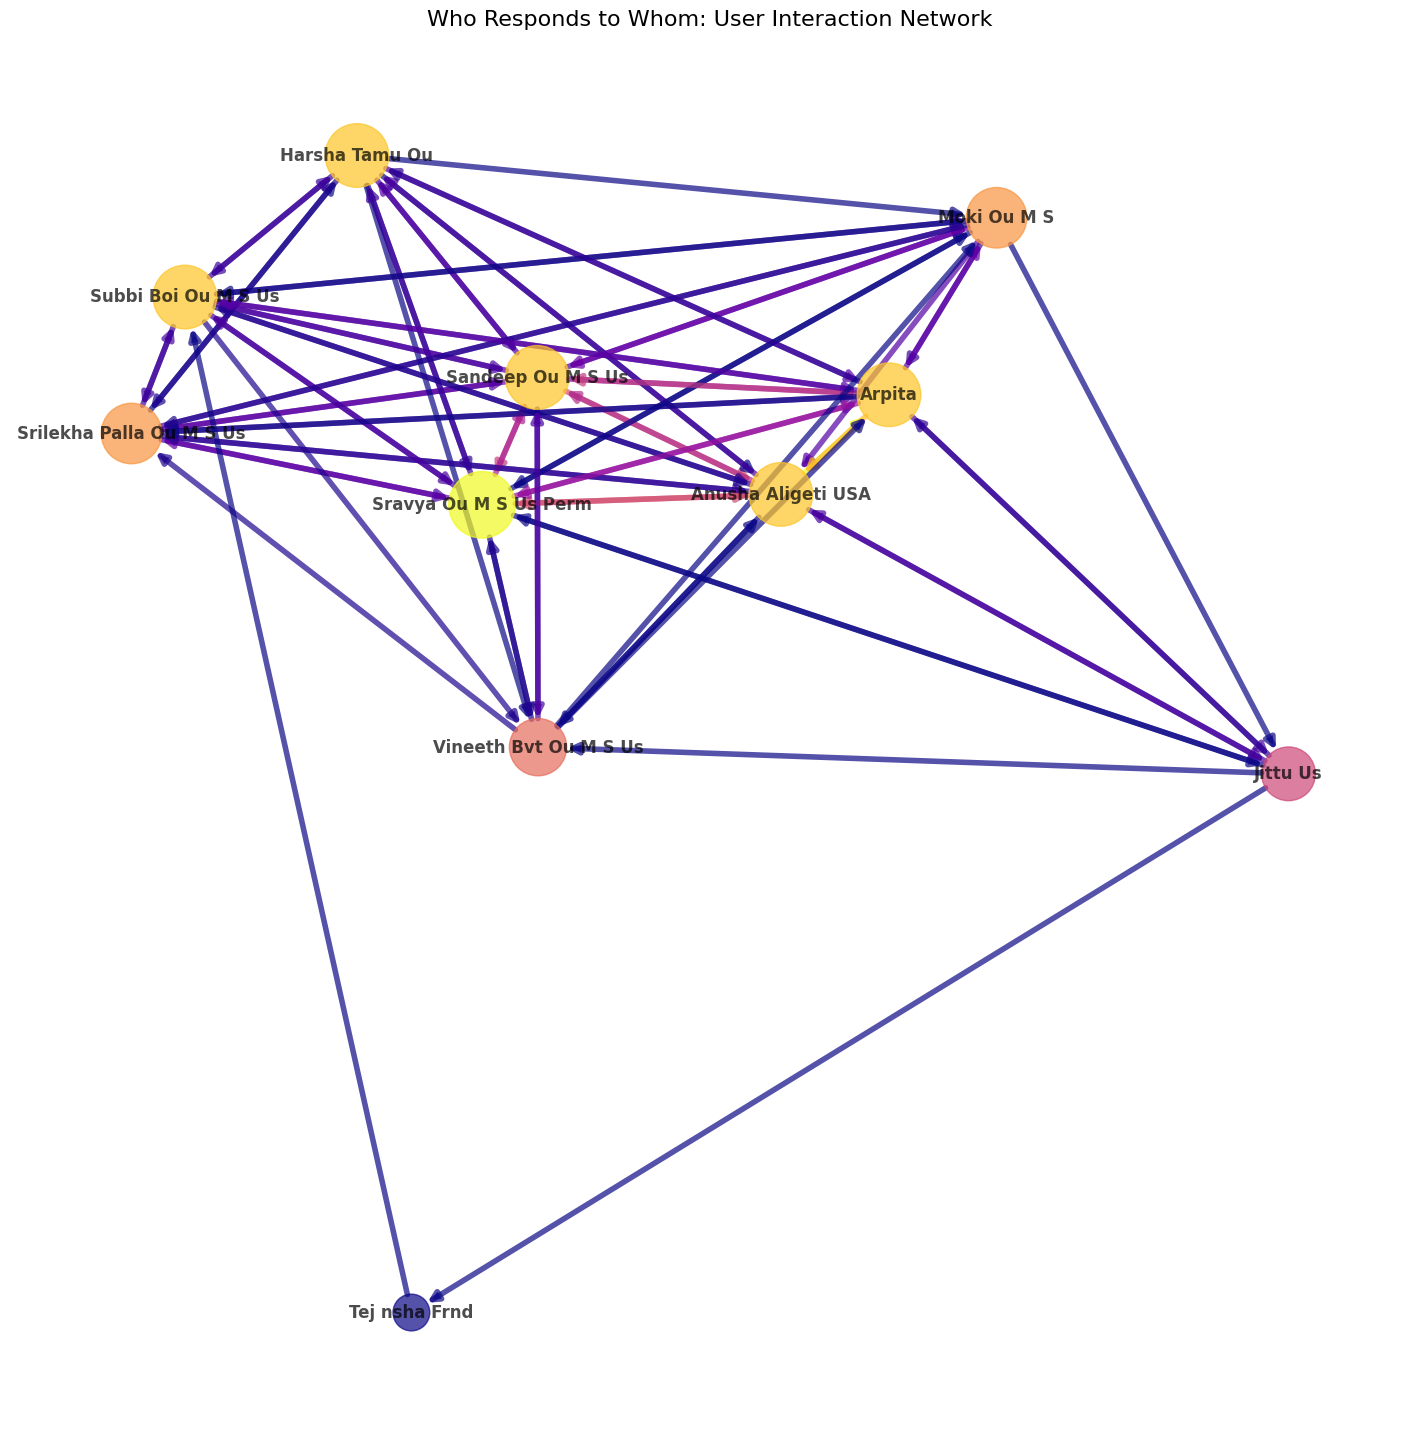

In [52]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Filter out 'Group Notification' users from the dataframe
filtered_df = df[df['User'] != 'Group Notification']

# Loop through the filtered messages and create edges between users, avoiding self-responses
for idx in range(1, len(filtered_df)):
    user1 = filtered_df['User'].iloc[idx-1]
    user2 = filtered_df['User'].iloc[idx]
    
    # Avoid self-responses (no edge between the same user)
    if user1 != user2:
        if G.has_edge(user1, user2):
            G[user1][user2]['weight'] += 1  # Increment edge weight if the edge already exists
        else:
            G.add_edge(user1, user2, weight=1)  # Add edge with initial weight

# Draw the directed interaction graph
plt.figure(figsize=(14, 14))

# Get the number of responses per user (for node color gradient)
user_response_count = {user: G.out_degree(user) for user in G.nodes}

# Get the edge weight for adjusting arrow thickness
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

# Get the color gradient based on user responses
node_color = [user_response_count[user] for user in G.nodes]
node_size = [500 + 200 * user_response_count[user] for user in G.nodes]  # Size of the node based on number of responses

# Draw the graph with custom settings
nx.draw(G, with_labels=True, node_size=node_size, node_color=node_color, 
        cmap=plt.cm.plasma, font_size=12, font_weight='bold', 
        edge_color=edge_weights, width=4, edge_cmap=plt.cm.plasma, arrows=True, 
        arrowsize=15, alpha=0.7)

# Title for the graph
plt.title('Who Responds to Whom: User Interaction Network', fontsize=16)
plt.show()

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

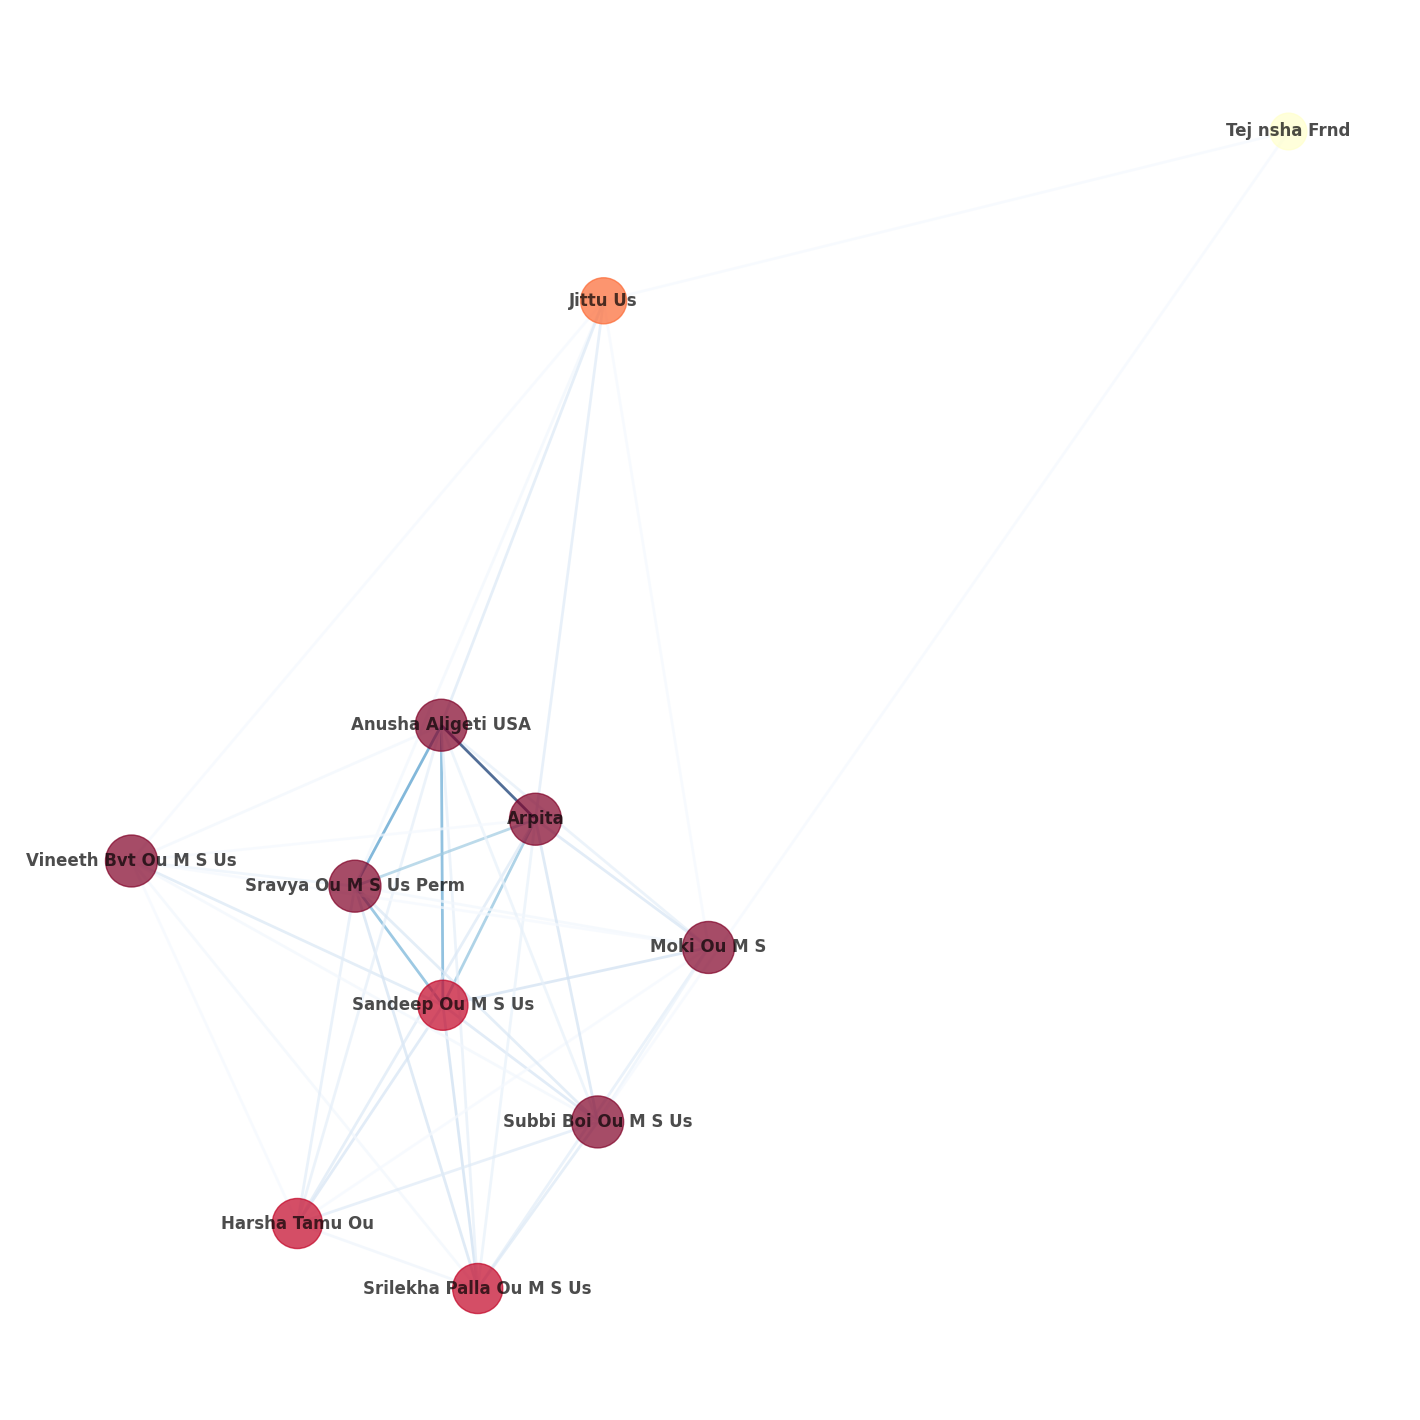

In [55]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Create an undirected graph (or directed if necessary)
G = nx.Graph()  # If you want a directed graph, use nx.DiGraph()

# Filter out 'Group Notification' users from the dataframe
filtered_df = df[df['User'] != 'Group Notification']

# Loop through the filtered messages and create edges between users, avoiding self-responses
for idx in range(1, len(filtered_df)):
    user1 = filtered_df['User'].iloc[idx-1]
    user2 = filtered_df['User'].iloc[idx]
    
    # Avoid self-responses (no edge between the same user)
    if user1 != user2:
        if G.has_edge(user1, user2):
            G[user1][user2]['weight'] += 1  # Increment edge weight if the edge already exists
        else:
            G.add_edge(user1, user2, weight=1)  # Add edge with initial weight

# Visualize the graph with the required properties
plt.figure(figsize=(14, 14))

# Get the number of responses per user (for node color gradient)
user_response_count = {user: G.degree(user) for user in G.nodes}

# Get the edge weight for adjusting edge color intensity
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

# Get the color gradient based on user responses (more active users have darker colors)
node_color = [user_response_count[user] for user in G.nodes]
node_size = [500 + 100 * user_response_count[user] for user in G.nodes]  # Size of the node based on activity level

# Draw the graph with custom settings
node_scatter = nx.draw(G, with_labels=True, node_size=node_size, node_color=node_color, 
                       cmap=plt.cm.YlOrRd, font_size=12, font_weight='bold', 
                       edge_color=edge_weights, width=2, edge_cmap=plt.cm.Blues, 
                       alpha=0.7, edge_vmin=0, edge_vmax=max(edge_weights))

# Add a color bar for the nodes
plt.colorbar(node_scatter, label='Node Activity Level')

# Add a custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=10, label='Active User'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', markersize=10, label='Less Active User')
]
plt.legend(handles=legend_elements, loc='upper right')

# Title for the graph
plt.title('Who Responds to Whom: User Interaction Network', fontsize=16)

# Show the graph
plt.show()

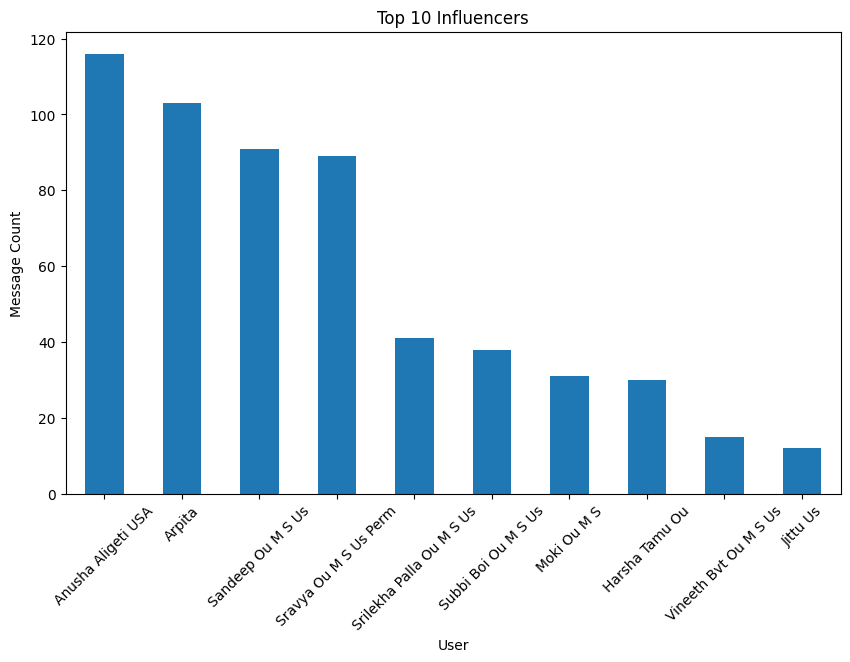

In [54]:
# Identify top users with the most messages
top_influencers = df['User'].value_counts().head(10)

# Plot influencers
top_influencers.plot(kind='bar', figsize=(10, 6), title='Top 10 Influencers')
plt.xlabel('User')
plt.ylabel('Message Count')
plt.xticks(rotation=45)
plt.show()